# 13 — Deep Learning Applications
**Goal:** See how the MLP from notebook 12 is specialized for images, text,
and sequences — CNN, RNN/LSTM, and the Transformer. Source: Géron
Ch11-15, Stanford CS231n, CS224n, MIT 6.S898.

In [1]:
import os
os.chdir('/Volumes/SSD_Gabo/proyectos/learning_courses')

import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
np.random.seed(13)

## 1. Why the architecture matters

A vanilla MLP applied to a 256×256 RGB image has ~200k input features. A
single dense layer mapping them to 1000 hidden units has **200 million
parameters** and no idea that neighboring pixels are related.

Each specialized architecture encodes an *inductive bias*:

| Architecture | Inductive bias | Use |
|---|---|---|
| **CNN** (LeCun 1989) | locality + translation invariance | images, audio |
| **RNN / LSTM / GRU** | sequentiality + parameter sharing | text, speech (legacy) |
| **Transformer** (Vaswani 2017) | all-pairs attention; no locality bias | text, code, images, audio |
| **GNN** (Kipf & Welling 2017) | graph structure | molecules, social networks |
| **Diffusion** (Ho 2020) | iterative denoising | image, audio generation |

In 2024 the Transformer is the dominant architecture in NLP and is taking
over vision and audio.

## 2. The convolutional layer

A **convolution** slides a small filter (e.g. 3×3) over the input and at
each position computes a dot product. The same filter is used at every
position — **weight sharing** — which is what gives translation invariance.

**Hyperparameters:**
- **Filter size** — typically 3×3 or 5×5 (receptive field).
- **Stride** — step size; >1 downsamples.
- **Padding** — 'same' keeps the output size; 'valid' shrinks.
- **Number of filters** — output depth.

After a convolution, an MLP has roughly **filter_size² × input_depth ×
num_filters** parameters per layer.

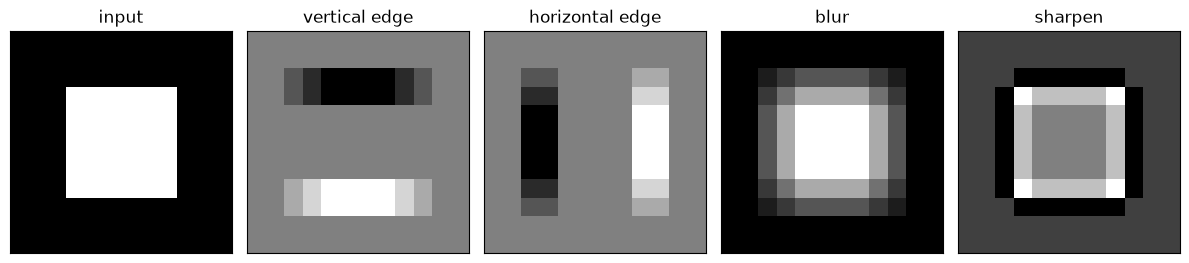

In [2]:
from scipy.signal import convolve2d
img = np.zeros((12, 12)); img[3:9, 3:9] = 1
kernels = {
    'vertical edge':  np.array([[-1,-1,-1], [0, 0, 0], [1, 1, 1]]),
    'horizontal edge':np.array([[-1, 0, 1], [-1, 0, 1], [-1, 0, 1]]),
    'blur':           np.ones((3, 3)) / 9,
    'sharpen':        np.array([[0,-1,0], [-1,5,-1], [0,-1,0]]),
}
fig, axes = plt.subplots(1, 5, figsize=(12, 3))
axes[0].imshow(img, cmap='gray'); axes[0].set_title('input')
for ax, (name, k) in zip(axes[1:], kernels.items()):
    ax.imshow(convolve2d(img, k, mode='same'), cmap='gray')
    ax.set_title(name)
for ax in axes: ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.show()

## 3. The CNN architecture

Stack CONV → ReLU → POOL blocks, then flatten and add a small MLP for the
final classification. Modern variants (ResNet, EfficientNet) add skip
connections and much more depth.

The classic LeNet-5 (1998) had 60k parameters; ResNet-50 (2015) has 25M;
GPT-3 (2020) has 175B. **The pattern is the same** — convolution,
nonlinearity, pooling, repeat.

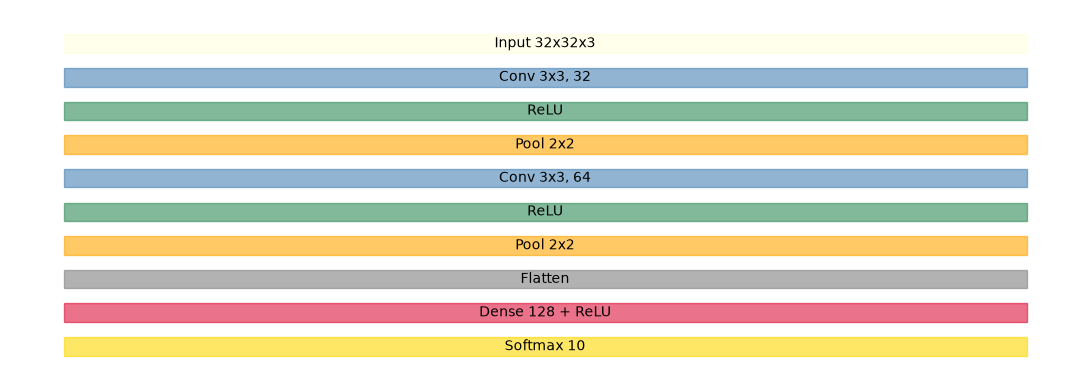

In [3]:
fig, ax = plt.subplots(figsize=(11, 4))
ax.axis('off'); ax.set_xlim(0, 1); ax.set_ylim(0, 1)
layers = [
    ('Input 32x32x3',    'lightyellow'),
    ('Conv 3x3, 32',     'steelblue'),
    ('ReLU',             'seagreen'),
    ('Pool 2x2',         'orange'),
    ('Conv 3x3, 64',     'steelblue'),
    ('ReLU',             'seagreen'),
    ('Pool 2x2',         'orange'),
    ('Flatten',          'gray'),
    ('Dense 128 + ReLU', 'crimson'),
    ('Softmax 10',       'gold'),
]
for i, (lbl, color) in enumerate(layers):
    y = 1 - (i+1) / (len(layers)+1)
    ax.add_patch(plt.Rectangle((0.05, y - 0.025), 0.9, 0.05, color=color, alpha=0.6))
    ax.text(0.5, y, lbl, ha='center', va='center', fontsize=10)
plt.tight_layout(); plt.show()

## 4. The recurrent layer

An RNN maintains a hidden state h_t that is updated at every step:

    h_t = tanh(W_xh x_t + W_hh h_{t-1} + b)

Same weights at every time step — **weight sharing over time**.
**Problem:** gradients vanish or explode over long sequences.
**Solutions:** LSTM (Hochreiter 1997) and GRU (Cho 2014) add a gating
mechanism that controls information flow. They are the dominant RNN
variants and the standard baseline for sequence modeling until 2017.

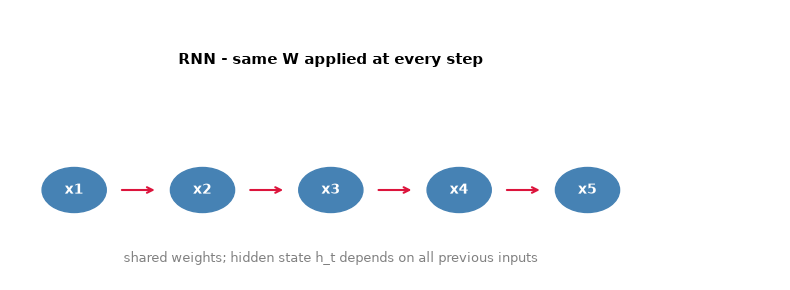

In [4]:
fig, ax = plt.subplots(figsize=(8, 3))
ax.axis('off'); ax.set_xlim(0, 6); ax.set_ylim(0, 3)
for t, x in enumerate(['x1', 'x2', 'x3', 'x4', 'x5']):
    ax.add_patch(plt.Circle((t+0.5, 1), 0.25, color='steelblue'))
    ax.text(t+0.5, 1, x, ha='center', va='center', color='white', fontsize=10, weight='bold')
    if t < 4:
        ax.annotate('', xy=(t+1.15, 1), xytext=(t+0.85, 1),
                    arrowprops=dict(arrowstyle='->', color='crimson', lw=1.5))
ax.text(2.5, 2.4, 'RNN - same W applied at every step', ha='center', fontsize=11, weight='bold')
ax.text(2.5, 0.2, 'shared weights; hidden state h_t depends on all previous inputs',
        ha='center', fontsize=9, color='gray')
plt.tight_layout(); plt.show()

## 5. Attention and the Transformer

**Scaled dot-product attention** (Vaswani et al. 2017) computes, for every
position, a weighted sum of all other positions, with weights learned from
the data:

    Attention(Q, K, V) = softmax(Q K^T / sqrt(d_k)) V

Q, K, V are linear projections of the input. Multi-head attention runs H
such attentions in parallel and concatenates. The Transformer is
attention + feed-forward + residual connections + layer norm, stacked.

Properties:
- **O(n²)** in sequence length — long-context models use sparse or linear
  variants.
- **No recurrence** — easy to parallelize on GPU.
- **No locality bias** — must learn it (positional encodings).

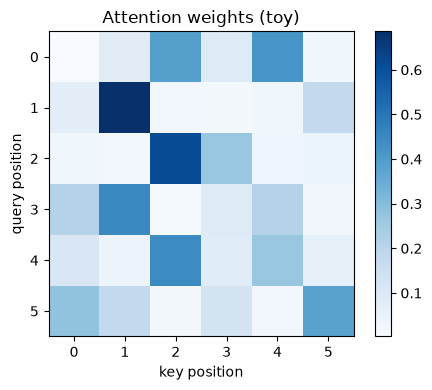

In [5]:
def softmax(x, axis=-1):
    x = x - x.max(axis=axis, keepdims=True)
    e = np.exp(x); return e / e.sum(axis=axis, keepdims=True)
np.random.seed(0)
n, d = 6, 16
X = np.random.randn(1, n, d)
Wq, Wk, Wv = (np.random.randn(d, d) * 0.3 for _ in range(3))
Q, K, V = X @ Wq, X @ Wk, X @ Wv
scores = Q @ K.transpose(0, 2, 1) / np.sqrt(d)
weights = softmax(scores, axis=-1)
out = weights @ V
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(weights[0], cmap='Blues')
ax.set_xticks(range(n)); ax.set_yticks(range(n))
ax.set_xlabel('key position'); ax.set_ylabel('query position')
ax.set_title('Attention weights (toy)')
fig.colorbar(im, ax=ax)
plt.tight_layout(); plt.show()

## 6. Transfer learning — the modern default

Training a large model from scratch is rare. The standard workflow:

1. **Take a pretrained model** (ResNet, ViT, BERT, GPT, Whisper).
2. **Replace the head** (the last few layers) for your task.
3. **Freeze** most of the network and train the head for a few epochs.
4. **Optionally unfreeze** and fine-tune the whole network with a small
   learning rate.

This works because pretrained features generalize surprisingly well across
tasks in the same modality.

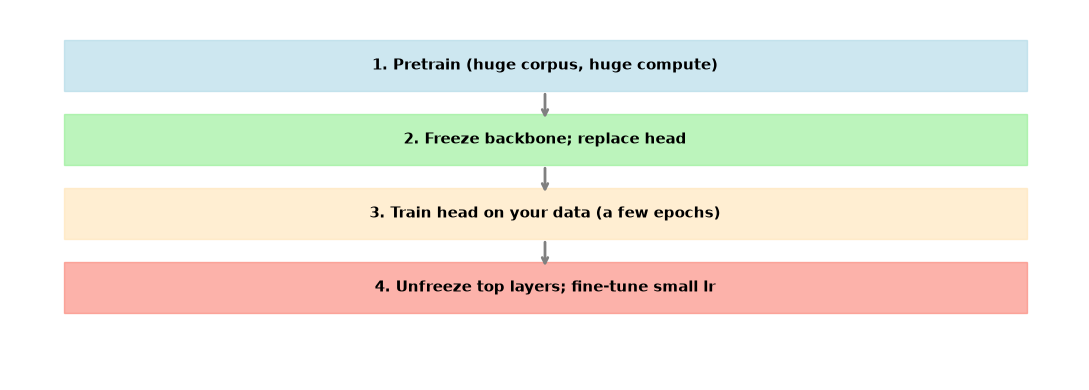

In [6]:
fig, ax = plt.subplots(figsize=(11, 4))
ax.axis('off'); ax.set_xlim(0, 1); ax.set_ylim(0, 1)
stages_text = [
    ('1. Pretrain (huge corpus, huge compute)', 'lightblue', 0.85),
    ('2. Freeze backbone; replace head',         'lightgreen', 0.65),
    ('3. Train head on your data (a few epochs)','moccasin', 0.45),
    ('4. Unfreeze top layers; fine-tune small lr','salmon', 0.25),
]
for label, color, y in stages_text:
    ax.add_patch(plt.Rectangle((0.05, y - 0.07), 0.9, 0.14, color=color, alpha=0.6))
    ax.text(0.5, y, label, ha='center', va='center', fontsize=11, weight='bold')
    if y > 0.3:
        ax.annotate('', xy=(0.5, y - 0.15), xytext=(0.5, y - 0.07), arrowprops=dict(arrowstyle='->', color='gray', lw=2))
plt.tight_layout(); plt.show()

## 7. Practical advice (Geron Ch14)

- **Start with a working baseline** — a small MLP or logistic regression on
  raw features. Beating this with a deep model is non-trivial.
- **Use a pretrained backbone** whenever the modality matches (image, text,
  audio, code).
- **Learning rate is the most important hyperparameter.** Try a range
  [1e-5, 1e-1] logarithmically.
- **Batch size** — start at 32, increase until GPU is full or loss gets
  noisy.
- **Schedule the learning rate** — cosine decay or step decay.
- **Early stop** on validation loss, save the best checkpoint.
- **Use mixed precision** (fp16) — ~2x speedup, no loss of quality.
- **Reproducibility:** set seeds, log hyperparameters, version data and
  code.

## 8. A worked example — fine-tuning a text classifier

Using HuggingFace transformers (if installed). The pattern:

1. Load a pretrained tokenizer and model.
2. Tokenize your dataset.
3. Replace the classification head.
4. Train with the standard PyTorch loop (or `Trainer` API).
5. Evaluate on a held-out set.

In [7]:
try:
    from transformers import AutoTokenizer, AutoModelForSequenceClassification
    print('transformers available - fine-tuning is straightforward')
    print('See https://huggingface.co/docs/transformers/training')
except ImportError:
    print('transformers not installed; uv add transformers datasets accelerate')

transformers not installed; uv add transformers datasets accelerate


## 9. Vision Transformers and beyond

**ViT (Dosovitskiy 2020):** chop the image into 16x16 patches, treat them as
tokens, feed to a Transformer. Works as well as CNNs when pretrained on
enough data.

**CLIP (Radford 2021):** train an image and a text encoder to align their
embeddings; enables zero-shot image classification with arbitrary text
labels.

**Diffusion (Ho 2020):** learn to iteratively denoise; produces state of the
art images. (Stable Diffusion, DALL-E 2, Imagen.)

**LLMs (Brown 2020):** Transformer trained on next-token prediction; scaling
shows emergent abilities. The dominant paradigm of 2020-2025.

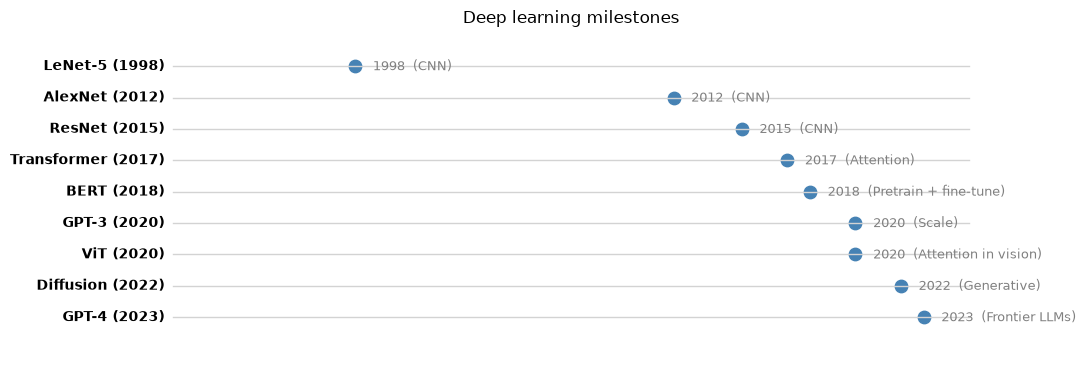

In [8]:
fig, ax = plt.subplots(figsize=(11, 4))
ax.axis('off'); ax.set_xlim(0, 1); ax.set_ylim(0, 1)
milestones = [
    ('LeNet-5 (1998)',          1998, 'CNN'),
    ('AlexNet (2012)',            2012, 'CNN'),
    ('ResNet (2015)',             2015, 'CNN'),
    ('Transformer (2017)',         2017, 'Attention'),
    ('BERT (2018)',                2018, 'Pretrain + fine-tune'),
    ('GPT-3 (2020)',              2020, 'Scale'),
    ('ViT (2020)',                 2020, 'Attention in vision'),
    ('Diffusion (2022)',  2022, 'Generative'),
    ('GPT-4 (2023)',       2023, 'Frontier LLMs'),
]
for i, (name, year, kind) in enumerate(milestones):
    y = 0.9 - i * 0.09
    ax.plot([0.05, 0.95], [y, y], color='lightgray', lw=1)
    ax.scatter((year - 1990) / 35 * 0.9 + 0.05, y, s=80, color='steelblue')
    ax.text(0.04, y, name, ha='right', va='center', fontsize=10, weight='bold')
    ax.text((year - 1990) / 35 * 0.9 + 0.07, y, str(year) + '  (' + kind + ')',
            ha='left', va='center', fontsize=9, color='gray')
ax.set_title('Deep learning milestones')
plt.tight_layout(); plt.show()

## Summary

| Architecture | Domain | Key idea |
|---|---|---|
| CNN | images, audio | convolution + weight sharing |
| RNN / LSTM | sequences (legacy) | recurrence + gating |
| Transformer | text, code, vision, audio | all-pairs attention |
| ViT | images | Transformer on patches |
| Diffusion | generation | iterative denoising |

| Practice | Recommendation |
|---|---|
| Start with | pretrained backbone, replace head |
| Tune first | learning rate, batch size, schedule |
| Use | mixed precision, early stopping, checkpointing |
| Always | set seeds, log everything |

**Next:** `14_advanced_topics.ipynb` - time series, recommenders, causal
inference, RL.